In [17]:
import h5py
import numpy as np
import bilby
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from bilby.gw.conversion import (
    chirp_mass_and_mass_ratio_to_component_masses,
    lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2,
    component_masses_to_chirp_mass,
    lambda_1_lambda_2_to_lambda_tilde,
)

rng        = np.random.default_rng(seed=42)
N_SAMPLES  = 5000
INPUT_FILE = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/restructured_networks.h5'

plt.rcParams.update({
    'text.usetex':     True,
    'font.family':     'serif',
    'font.size':       18,
    'axes.labelsize':  18,
    'axes.titlesize':  14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

In [18]:
with h5py.File(INPUT_FILE, 'r') as f:
    bns_networks  = list(f['BNS'].keys())
    nsbh_networks = list(f['NSBH'].keys())
    eos_mass      = f['eos_metadata']['mass_msol'][:]
    eos_lambda    = f['eos_metadata']['lambda'][:]
    m_max_tov     = float(f['eos_metadata'].attrs['M_max_TOV'])

print(f'BNS:  {len(bns_networks)} networks')
print(f'NSBH: {len(nsbh_networks)} networks')
print(f'M_max_TOV: {m_max_tov:.4f} Msol')

BNS:  35 networks
NSBH: 35 networks
M_max_TOV: 2.0645 Msol


In [19]:
def draw_samples_for_event(net_grp, idx, n_samples=N_SAMPLES, rng=rng):
    def sample(param):
        return rng.normal(float(net_grp[f'mu_{param}'][idx]), float(net_grp[f'sigma_{param}'][idx]), size=n_samples)

    Mc_src      = sample('Mc_src')
    dL          = sample('dL')
    LambdaTilde = sample('LambdaTilde')
    deltaLambda = sample('deltaLambda')
    psi         = sample('psi')
    q           = np.clip(sample('q'), 1e-6, 1.0)

    m1_src, m2_src = chirp_mass_and_mass_ratio_to_component_masses(Mc_src, q)
    Lambda1, Lambda2 = lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2(
        LambdaTilde, deltaLambda, m1_src, m2_src
    )
    Lambda1 = np.clip(Lambda1, 0.0, None)

    return {
        'Mc_src':       Mc_src,
        'q':            q,
        'm1_src':       m1_src,
        'm2_src':       m2_src,
        'dL':           dL,
        'z':            float(net_grp['z'][idx]),
        'LambdaTilde':  LambdaTilde,
        'deltaLambda':  deltaLambda,
        'Lambda1':      Lambda1,
        'Lambda2':      Lambda2,
        'psi':          psi,
        'snr':          float(net_grp['snr'][idx]),
        'sky_area_90':  float(net_grp['sky_area_90'][idx]),
        'm1_src_inj':   float(net_grp['m1_src'][idx]),
        'm2_src_inj':   float(net_grp['m2_src'][idx]),
        'Lambda1_inj':  float(net_grp['Lambda1'][idx]),
        'Lambda2_inj':  float(net_grp['Lambda2'][idx]),
    }

In [20]:
with h5py.File(INPUT_FILE, 'r') as f:
    result = draw_samples_for_event(f['BNS'][bns_networks[0]], 0)

print(f"snr: {result['snr']:.2f}   sky_area_90: {result['sky_area_90']:.2f} deg^2")
print()
for param in ['Mc_src','q','m1_src','m2_src','dL','LambdaTilde','deltaLambda','Lambda1','Lambda2','psi']:
    arr = result[param]
    print(f"{param:20s}: median={np.median(arr):.4f}  std={np.std(arr):.4f}  [{np.percentile(arr,5):.4f}, {np.percentile(arr,95):.4f}]")

print()
print('injection vs sample median')
print(f"m1_src  inj={result['m1_src_inj']:.4f}  median={np.median(result['m1_src']):.4f}")
print(f"m2_src  inj={result['m2_src_inj']:.4f}  median={np.median(result['m2_src']):.4f}")
print(f"Lambda1 inj={result['Lambda1_inj']:.4f}  median={np.median(result['Lambda1']):.4f}")
print(f"Lambda2 inj={result['Lambda2_inj']:.4f}  median={np.median(result['Lambda2']):.4f}")


snr: 17.07   sky_area_90: 121.36 deg^2

Mc_src              : median=1.3453  std=0.0002  [1.3450, 1.3456]
q                   : median=0.8797  std=0.3150  [0.0299, 1.0000]
m1_src              : median=1.6484  std=1088.4417  [1.5451, 11.1257]
m2_src              : median=1.4501  std=0.3886  [0.3323, 1.5456]
dL                  : median=8.0705  std=1.8808  [5.0238, 11.2022]
LambdaTilde         : median=170.4109  std=43.1359  [101.2653, 245.1943]
deltaLambda         : median=26.8425  std=95.2435  [-129.0868, 183.2496]
Lambda1             : median=82.7434  std=183.2902  [0.0000, 407.3003]
Lambda2             : median=292.6999  std=173694405734564416.0000  [-35693.5276, 6802.5679]
psi                 : median=2.0966  std=0.9007  [0.5863, 3.5977]

injection vs sample median
m1_src  inj=1.6542  median=1.6484
m2_src  inj=1.4450  median=1.4501
Lambda1 inj=101.7593  median=82.7434
Lambda2 inj=273.9868  median=292.6999


In [21]:
def load_plot_data(f, population, networks):
    net_detected = {n: int(f[population][n].attrs['detected_events']) for n in networks}
    sorted_nets  = sorted(net_detected, key=lambda n: net_detected[n])[:6]
    data = {}
    for net in sorted_nets:
        grp = f[population][net]
        data[net] = {
            'Mc':       grp['mu_Mc_src'][:],
            'LT':       grp['mu_LambdaTilde'][:],
            'sigma_LT': grp['sigma_LambdaTilde'][:],
            'sigma_Mc': grp['sigma_Mc_src'][:],
            'n':        int(grp.attrs['detected_events']),
        }
    return sorted_nets, data

with h5py.File(INPUT_FILE, 'r') as f:
    sorted_bns,  bns_data  = load_plot_data(f, 'BNS',  bns_networks)
    sorted_nsbh, nsbh_data = load_plot_data(f, 'NSBH', nsbh_networks)

lambda_of_mass = interp1d(eos_mass, eos_lambda, bounds_error=False, fill_value=np.nan)
rng_eos        = np.random.default_rng(0)
N_ref          = 50000
m1_ref         = rng_eos.uniform(1.0, m_max_tov, N_ref)
m2_ref         = rng_eos.uniform(1.0, m_max_tov, N_ref)
m1_ref, m2_ref = np.maximum(m1_ref, m2_ref), np.minimum(m1_ref, m2_ref)
L1_ref         = lambda_of_mass(m1_ref)
L2_ref         = lambda_of_mass(m2_ref)
Mc_ref         = component_masses_to_chirp_mass(m1_ref, m2_ref)
LT_ref         = lambda_1_lambda_2_to_lambda_tilde(L1_ref, L2_ref, m1_ref, m2_ref)
sort_idx       = np.argsort(Mc_ref)
Mc_ref         = Mc_ref[sort_idx]
LT_ref         = LT_ref[sort_idx]

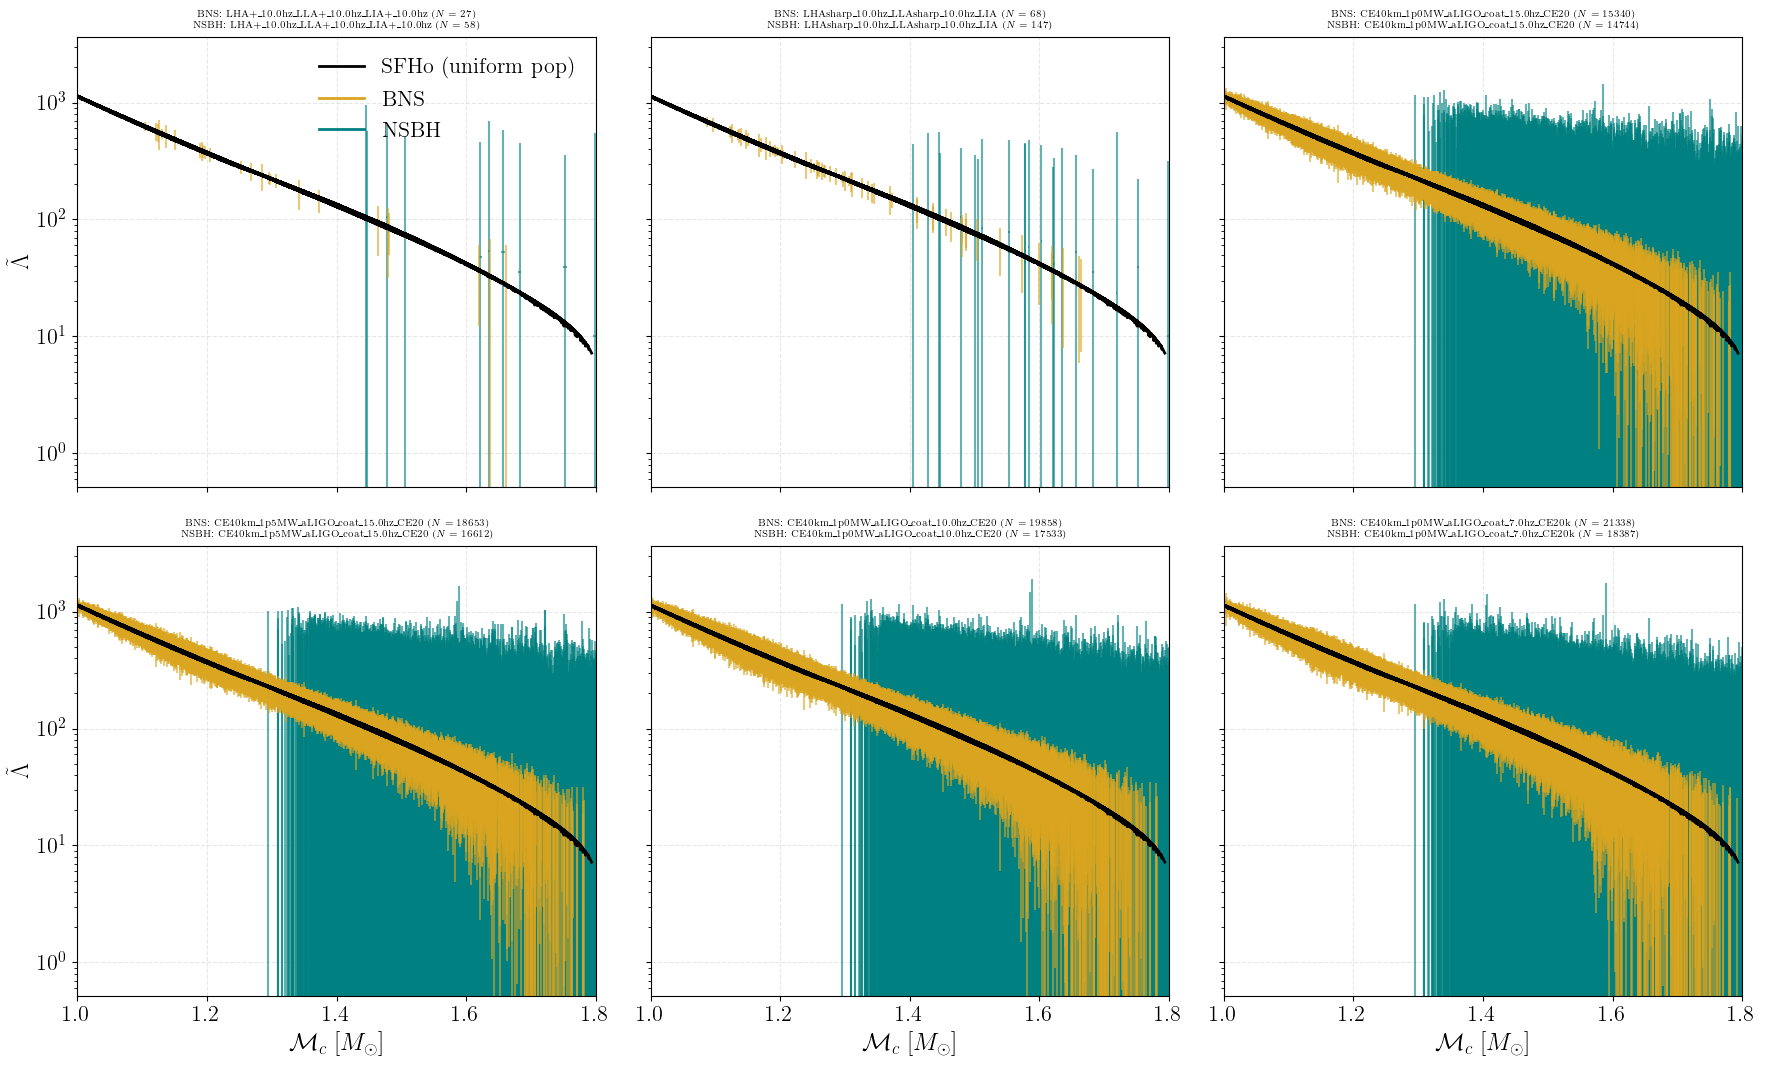

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=True, sharex=True)

for ax, bns_net, nsbh_net in zip(axes.flatten(), sorted_bns, sorted_nsbh):
    db = bns_data[bns_net]
    dn = nsbh_data[nsbh_net]
    mb = (db['LT'] < 1e5) & (db['LT'] > 0)
    mn = (dn['LT'] < 1e5) & (dn['LT'] > 0)

    ax.semilogy(Mc_ref, LT_ref, color='black', lw=2, zorder=5)
    ax.errorbar(dn['Mc'][mn], dn['LT'][mn], yerr=dn['sigma_LT'][mn], xerr=dn['sigma_Mc'][mn],
                fmt='none', alpha=0.6, color='teal', label='NSBH')
    ax.errorbar(db['Mc'][mb], db['LT'][mb], yerr=db['sigma_LT'][mb], xerr=db['sigma_Mc'][mb],
                fmt='none', alpha=0.6, color='goldenrod', label='BNS')

    ax.set_title(
        f'BNS: {bns_net[:35]} ($N={db["n"]}$)\nNSBH: {nsbh_net[:35]} ($N={dn["n"]}$)',
        fontsize=7
    )
    ax.set_xlim(1.0, 1.8)
    ax.grid(alpha=0.3, ls='--')
    if ax in axes[:, 0]:
        ax.set_ylabel(r'$\tilde{\Lambda}$')
    if ax in axes[1, :]:
        ax.set_xlabel(r'$\mathcal{M}_c\ [M_\odot]$')

handles = [
    plt.Line2D([0], [0], color='black',     lw=2, label='SFHo (uniform pop)'),
    plt.Line2D([0], [0], color='goldenrod', lw=2, label='BNS'),
    plt.Line2D([0], [0], color='teal',      lw=2, label='NSBH'),
]
axes[0, 0].legend(handles=handles, frameon=False)
plt.tight_layout()
plt.show()

In [23]:
print('sorted BNS:')
for n in sorted_bns:
    print(f'  {n}: {bns_data[n]["n"]}')
print('sorted NSBH:')
for n in sorted_nsbh:
    print(f'  {n}: {nsbh_data[n]["n"]}')

sorted BNS:
  LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz: 27
  LHAsharp_10.0hz_LLAsharp_10.0hz_LIAsharp_10.0hz: 68
  CE40km_1p0MW_aLIGO_coat_15.0hz_CE20km_1p0MW_aLIGO_coat_15.0hz_LIA+_10.0hz: 15340
  CE40km_1p5MW_aLIGO_coat_15.0hz_CE20km_1p5MW_aLIGO_coat_15.0hz_LIA+_10.0hz: 18653
  CE40km_1p0MW_aLIGO_coat_10.0hz_CE20km_1p0MW_aLIGO_coat_10.0hz_LIA+_10.0hz: 19858
  CE40km_1p0MW_aLIGO_coat_7.0hz_CE20km_1p0MW_aLIGO_coat_7.0hz_LIA+_10.0hz: 21338
sorted NSBH:
  LHA+_10.0hz_LLA+_10.0hz_LIA+_10.0hz: 58
  LHAsharp_10.0hz_LLAsharp_10.0hz_LIAsharp_10.0hz: 147
  CE40km_1p0MW_aLIGO_coat_15.0hz_CE20km_1p0MW_aLIGO_coat_15.0hz_LIA+_10.0hz: 14744
  CE40km_1p5MW_aLIGO_coat_15.0hz_CE20km_1p5MW_aLIGO_coat_15.0hz_LIA+_10.0hz: 16612
  CE40km_1p0MW_aLIGO_coat_10.0hz_CE20km_1p0MW_aLIGO_coat_10.0hz_LIA+_10.0hz: 17533
  CE40km_1p0MW_aLIGO_coat_7.0hz_CE20km_1p0MW_aLIGO_coat_7.0hz_LIA+_10.0hz: 18387
